# DATASET EXPLORATION

In [1]:
import os
from pathlib import Path
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

DATASET_PATH = Path("/home/betenk/Documents/Porto/datasets/anpr-model-1.v1i.yolov11")

# Cek Struktur Dataset

In [2]:
print(DATASET_PATH)

print("\nIsi Folder:")
for item in DATASET_PATH.iterdir():
    print(f"  {item.name}")

/home/betenk/Documents/Porto/datasets/anpr-model-1.v1i.yolov11

Isi Folder:
  valid
  test
  data.yaml
  README.dataset.txt
  train
  README.roboflow.txt


# Data Yaml read

In [3]:
yaml_path = DATASET_PATH / "data.yaml"
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

data_yaml


{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 2,
 'names': ['plate', 'toyota'],
 'roboflow': {'workspace': 'anpr-n2dbe',
  'project': 'anpr-model-1',
  'version': 1,
  'license': 'MIT',
  'url': 'https://universe.roboflow.com/anpr-n2dbe/anpr-model-1/dataset/1'}}

# Show Nama class

In [4]:
print("Jumlah Kelas:", data_yaml['nc'])
print("Nama Kelas:", data_yaml['names'])

Jumlah Kelas: 2
Nama Kelas: ['plate', 'toyota']


# Hitung Jumlah Gambar

In [5]:
splits = [ "train", "val", "test" ]

for split in splits:
    image_dir = DATASET_PATH / split / "images"
    total = len(list(image_dir.glob("*")))

    print(f"{split:<6}:{total:>5} images")

train :  676 images
val   :    0 images
test  :   96 images


# Menghitung Label

In [6]:
for split in splits:
    label_dir = DATASET_PATH / split / "labels"
    total = len(list(label_dir.glob("*")))

    print(f"{split:<6}:{total:>5} labels")

train :  676 labels
val   :    0 labels
test  :   96 labels


# Show example image

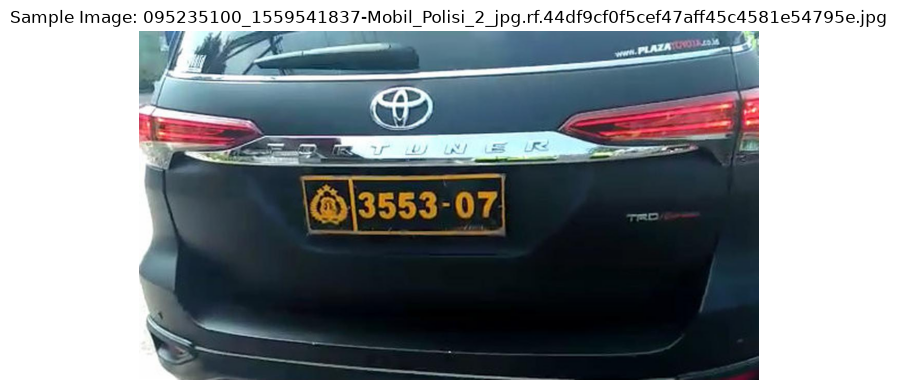

In [7]:
image_dir = DATASET_PATH / "train" / "images"

images_files = sorted(image_dir.glob("*")
)

sample = images_files[0]

img = cv2.imread(str(sample))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Sample Image: {sample.name}")
plt.show()

# Membaca Label Yolo

In [8]:
label_path = DATASET_PATH / "train" / "labels" / (sample.stem + ".txt")

with open(label_path) as f:
    labels = f.readlines()
    labels

# Menggambar Bounding Box

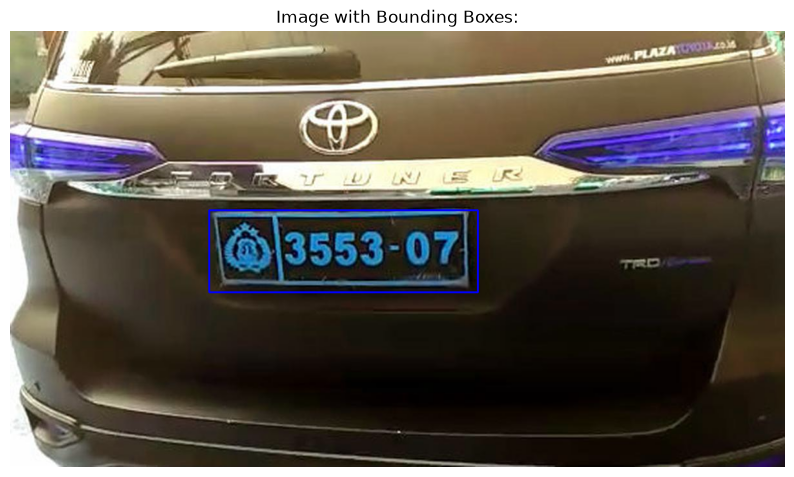

In [9]:
image = img.copy()

h, w = image.shape[:2]

for label in labels:
    cls, xc, yc, bw, bh = map(float, label.split())

    x1 = int((xc - bw / 2) * w)
    y1 = int((yc - bh / 2) * h)
    x2 = int((xc + bw / 2) * w)
    y2 = int((yc + bh / 2) * h)

    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Image with Bounding Boxes:")
plt.show()

# STATS DATA

In [10]:
stats = {}

for split in splits:

    stats[split] = len(list((DATASET_PATH / split / "images").glob("*")))
    stats

# Visualisasi Statistik

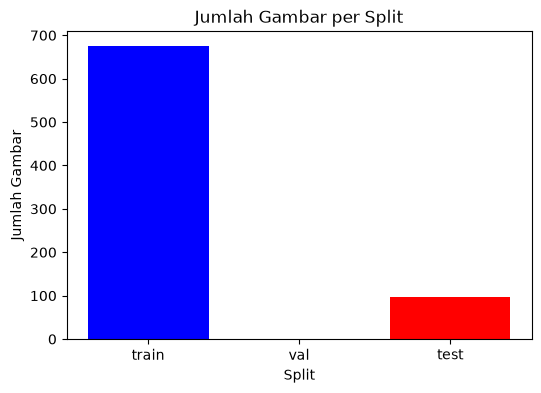

In [11]:
plt.figure(figsize=(6, 4))

plt.bar(stats.keys(), stats.values(), color=['blue', 'green', 'red'])

plt.title("Jumlah Gambar per Split")
plt.xlabel("Split")
plt.ylabel("Jumlah Gambar")
plt.show()